=== Unmatched files (category could not be determined) ===


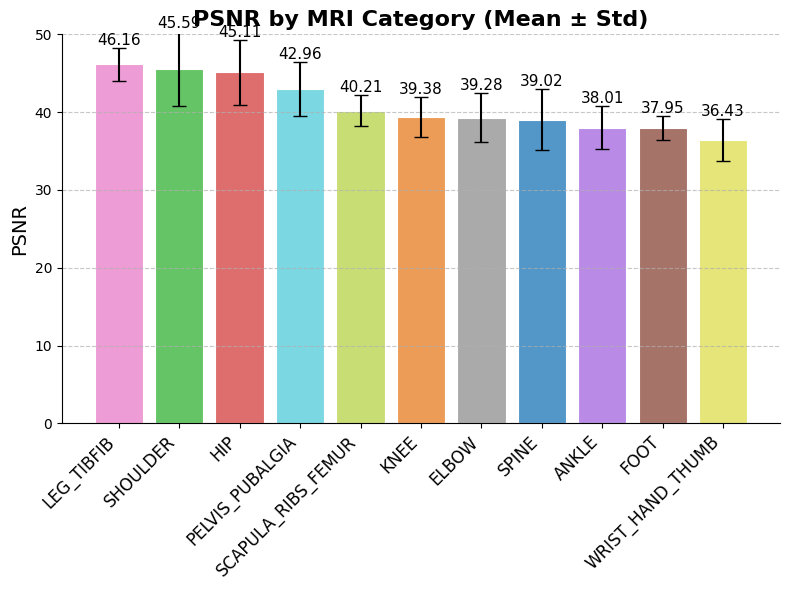

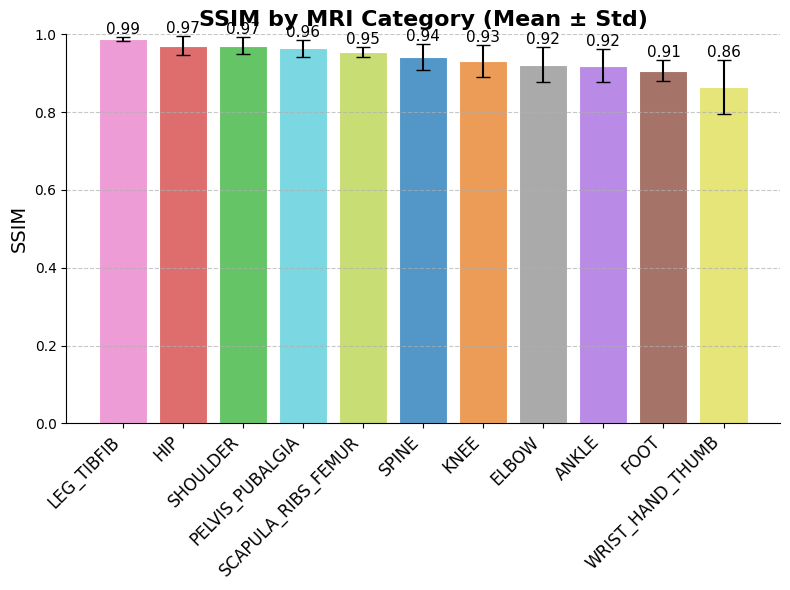

Global average PSNR: 40.56
Global average SSIM: 0.9446
Global PSNR from file: 40.76
Global SSIM from file: 0.9457


In [5]:
import os, json, h5py, xml.dom.minidom as minidom
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- CONFIG: set these ----------
#results_path = "./outputs/msk_baseline/msk_casc16_acc8"
#results_path = "/home/paula/msk_mri_dataset/HUMUS-Net/humusnet_val_outputs_msk"
results_path = "/home/paula/msk_mri_dataset/varnet/outputs/january_exps/test_on_msk/varnet_mskmrpro_FULL_casc8_acc8"
#results_path="/home/paula/msk_mri_dataset/varnet/outputs/january_exps/anatomies_full/varnet_msk_anatomy_scapula_ribs_femur_casc8_acc8"
json_path = results_path + "/metrics.json"   # path to your JSON above
data_dir  = "../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_test"  # folder containing the .h5 files
# --------------------------------------

scan_categories = {
    "SPINE": {"includes": ["L-SPINE","LSPINE","L SPINE","C-SPINE","CSPINE","C SPINE","T-SPINE","T SPINE",
                           "AX T2 T-SP","AX T2 T-SP WARP"]},
    "KNEE": {"includes": ["LT KNEE","RT KNEE"]},
    "SHOULDER": {"includes": ["LT SHOULDER","RT SHOULDER"]},
    "HIP": {"includes": ["LT HIP","RT HIP"]},
    "ANKLE": {"includes": ["LT ANKLE","RT ANKLE"]},
    "FOOT": {"includes": ["LT FOOT","RT FOOT"]},
    "LEG_TIBFIB": {"includes": ["LT LEG","RT TIB-FIB"]},
    "ELBOW": {"includes": ["LT ELBOW","RT ELBOW"]},
    "WRIST_HAND_THUMB": {"includes": ["LT WRIST","RT WRIST","LT THUMB","RT THUMB","RT HAND","WRIST RT"]},
    "PELVIS_PUBALGIA": {"includes": ["PELVIS","ATH PUBALGIA"]},
    "SCAPULA_RIBS_FEMUR": {"includes": ["RT SCAPULA","RIBS","LT FEMUR"]},
}

# Fixed colors per category (stable across runs/plots).
# Feel free to tweak these, but keep keys exactly matching scan_categories.
CATEGORY_COLORS = {
    "SPINE": "#5297c8",            # blue
    "KNEE": "#ec9c57",             # orange
    "SHOULDER": "#65c465",         # green
    "HIP": "#de6e6e",              # red
    "ANKLE": "#ba8be6",            # purple
    "FOOT": "#a67369",             # brown
    "LEG_TIBFIB": "#ed9cd5",       # pink
    "ELBOW": "#aaaaaa",            # gray
    "WRIST_HAND_THUMB": "#e5e579", # olive/yellow-green
    "PELVIS_PUBALGIA": "#7bd7e2",  # cyan
    "SCAPULA_RIBS_FEMUR": "#c8dd74" # amber
}

def parse_header_study_and_patient(h5_path):
    """Return (tStudyDescription, patientID) from ismrmrd_header; None if missing."""
    try:
        with h5py.File(h5_path, "r") as f:
            if "ismrmrd_header" not in f:
                return None, None
            xml_raw = f["ismrmrd_header"][()]
            if isinstance(xml_raw, (bytes, bytearray, np.void)):
                xml_str = bytes(xml_raw).decode(errors="ignore")
            else:
                xml_str = str(xml_raw)
        dom = minidom.parseString(xml_str)
        # generic helper
        def _first_text(parent, tag):
            nodes = parent.getElementsByTagName(tag)
            if nodes and nodes[0].firstChild:
                return nodes[0].firstChild.data.strip()
            return None

        # userParameters may have name/value pairs
        study = None
        ups = dom.getElementsByTagName("userParameterString")
        for node in ups:
            name = _first_text(node, "name")
            if name == "tStudyDescription":
                study = _first_text(node, "value")
                break

        # fallback: try studyInformation/studyDescription (not always present)
        if study is None:
            study = _first_text(dom, "studyDescription")

        # patientID (typical location: subjectInformation/patientID)
        pid = None
        sub = dom.getElementsByTagName("subjectInformation")
        if sub:
            pid = _first_text(sub[0], "patientID")

        return study, pid
    except Exception:
        return None, None

def categorize(study_desc):
    if not study_desc:
        return None
    s = study_desc.upper()
    for cat, info in scan_categories.items():
        for token in info["includes"]:
            if token in s:
                return cat
    return None

# --------- Load JSON ----------
with open(json_path, "r") as f:
    metrics_json = json.load(f)

per_vol = metrics_json.get("per_volume", {})
global_psnr_file = metrics_json.get("global", {}).get("PSNR").get("mean")
global_ssim_file = metrics_json.get("global", {}).get("SSIM").get("mean")

# --------- Build table ----------
rows = []
unmatched = []
for fname, m in per_vol.items():
    h5_path = os.path.join(data_dir, fname)
    study, pid = parse_header_study_and_patient(h5_path)
    cat = categorize(study)
    if cat is None:
        unmatched.append((fname, study))
    rows.append({
        "file": fname,
        "category": cat,
        "study": study,
        "patientID": pid,
        "PSNR": m.get("PSNR"),
        "SSIM": m.get("SSIM"),
    })

df = pd.DataFrame(rows)

# --------- Print unmatched and patient counts ----------
print("=== Unmatched files (category could not be determined) ===")
for fname, study in unmatched:
    print(f"- {fname} | tStudyDescription={study}")

df_matched = df.dropna(subset=["category"])

def plot_metric(metric_name):
    g = df_matched.groupby("category")[metric_name]
    means = g.mean().sort_values(ascending=False)
    stds  = g.std().reindex(means.index)

    default_color = "#9e9e9e"  # fallback gray for unexpected categories
    bar_colors = [CATEGORY_COLORS.get(cat, default_color) for cat in means.index]

    plt.figure(figsize=(8, 6))
    bars = plt.bar(
        range(len(means)),
        means.values,
        yerr=stds.values,
        capsize=5,
        color=bar_colors,
        edgecolor="white",
        linewidth=0.8,
    )

    plt.xticks(range(len(means)), means.index, rotation=45, ha='right', fontsize=12)
    plt.ylabel(metric_name, fontsize=14)
    plt.title(f"{metric_name} by MRI Category (Mean ± Std)", fontsize=16, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().set_facecolor('white')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.ylim(0, 50.0 if metric_name == "PSNR" else 1.0)

    # Add value labels on top of bars
    for bar, mean, std in zip(bars, means.values, stds.values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0 if np.isnan(std) else std),
            f"{mean:.2f}",
            ha='center',
            va='bottom',
            fontsize=11,
        )

    plt.tight_layout()

for metric in ["PSNR", "SSIM"]:
    plot_metric(metric)

plt.show()

global_psnr = df["PSNR"].mean()
global_ssim = df["SSIM"].mean()

print(f'Global average PSNR: {global_psnr:.2f}')
print(f'Global average SSIM: {global_ssim:.4f}')
print(f'Global PSNR from file: {global_psnr_file:.2f}')
print(f'Global SSIM from file: {global_ssim_file:.4f}')

# save plots of the files that achieve less than 25 psnr or 0.55 of ssim

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

data_dir = "../../../../../data/datasets/msk_mri_h5/varnet_mrpro"
output_dir = "./outputs/low_quality_pngs"
varnet_png_dir = "./outputs/varnet_inference_mrpro_full_dataset"
os.makedirs(output_dir, exist_ok=True)
MAX_PLOTS = 20
print(f'Saving grid images of up to {MAX_PLOTS} slices from reconstruction_rss for low-quality files to {output_dir}:')

for idx, row in low_quality.iterrows():
    fname = row['file']
    psnr = row['PSNR']
    ssim = row['SSIM']
    category = row['category'] if row['category'] else 'Unknown'
    h5_path = os.path.join(data_dir, fname)
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    try:
        h5_size_mb = os.path.getsize(h5_path) / (1024 * 1024)
        with h5py.File(h5_path, "r") as f:
            if 'reconstruction_rss' not in f:
                print(f"'reconstruction_rss' not found in {fname}")
                continue
            recon = f['reconstruction_rss'][()]
            num_slices = recon.shape[0]
            n_plot = min(MAX_PLOTS, num_slices)
            shape_str = str(recon.shape)

            # --- First: create the grid of slices with its title ---
            grid_fig, grid_axes = plt.subplots(4, 5, figsize=(20, 16))
            grid_fig.suptitle(f"{fname} | {category} | PSNR={psnr:.2f} | SSIM={ssim:.2f} | shape={shape_str} | size={h5_size_mb:.1f}MB", fontsize=18, weight='bold')
            for i in range(n_plot):
                ax = grid_axes[i // 5, i % 5]
                ax.imshow(recon[i], cmap='gray')
                ax.set_title(f"Slice {i}", fontsize=10)
                ax.axis('off')
            for i in range(n_plot, 20):
                ax = grid_axes[i // 5, i % 5]
                ax.axis('off')
            grid_fig.tight_layout(rect=[0, 0.03, 1, 0.95])

            # Save the grid to a temporary PNG
            temp_grid_path = os.path.join(output_dir, "_temp_grid.png")
            grid_fig.savefig(temp_grid_path, bbox_inches='tight', pad_inches=0.1)
            plt.close(grid_fig)

            # --- Second: stack the VarNet output PNG below the grid ---
            png_base = os.path.splitext(os.path.basename(fname))[0]
            png_candidates = [f for f in os.listdir(varnet_png_dir) if png_base in f and f.lower().endswith('.png')]
            if png_candidates:
                varnet_png_path = os.path.join(varnet_png_dir, png_candidates[0])
                try:
                    grid_img = plt.imread(temp_grid_path)
                    varnet_img = plt.imread(varnet_png_path)
                    # Create stacked figure
                    fig, axes = plt.subplots(2, 1, figsize=(20, 24), gridspec_kw={'height_ratios': [4, 1]})
                    axes[0].imshow(grid_img)
                    axes[0].axis('off')
                    axes[1].imshow(varnet_img)
                    axes[1].set_title("VarNet Output", fontsize=16, color='blue')
                    axes[1].axis('off')
                    plt.tight_layout()
                    png_name = f"{category}_{png_base}_grid_with_varnet.png"
                    png_path = os.path.join(output_dir, png_name)
                    plt.savefig(png_path, bbox_inches='tight', pad_inches=0.1)
                    plt.close(fig)
                    print(f"Saved stacked grid image for {fname} ({category}, PSNR={psnr:.2f}, shape={shape_str}, size={h5_size_mb:.1f}MB) with VarNet output")
                except Exception as e:
                    print(f"Error loading PNG {varnet_png_path} or stacking: {e}")
            else:
                # Only save the grid if no VarNet PNG found
                png_name = f"{category}_{png_base}_grid_with_varnet.png"
                png_path = os.path.join(output_dir, png_name)
                os.rename(temp_grid_path, png_path)
                print(f"Saved grid image for {fname} ({category}, PSNR={psnr:.2f}, shape={shape_str}, size={h5_size_mb:.1f}MB) (no VarNet output)")

            # Remove temp grid file if exists
            if os.path.exists(temp_grid_path):
                os.remove(temp_grid_path)
    except Exception as e:
        print(f"Error reading {h5_path}: {e}")

Saving grid images of up to 20 slices from reconstruction_rss for low-quality files to ./outputs/low_quality_pngs:


# Rename PNGs with scan category prefix

In [ ]:
# # Rename PNGs in ./outputs/varnet_inference_mrpro_full_dataset with scan category prefix
# import os


# # Build a mapping from file name to scan category using the DataFrame from previous cells
# file_to_category = dict(zip(df['file'], df['category']))

# for fname in os.listdir(results_path):
#     if fname.lower().endswith('.png'):
#         # Try to find the scan category for this PNG
#         # Assume PNG filename contains the base file name (without extension) from df['file']
#         base_name = fname.split('.h5')[0]
#         # Find matching entry in df['file']
#         matched = [cat for f, cat in file_to_category.items() if base_name in f]
#         if matched and matched[0]:
#             prefix = matched[0]
#             new_name = f"{prefix}_{fname}"
#             src = os.path.join(results_path, fname)
#             dst = os.path.join(results_path, new_name)
#             os.rename(src, dst)
#             print(f"Renamed {fname} -> {new_name}")
#         else:
#             print(f"No category found for {fname}, skipping.")

Renamed meas_MID00485_FID113956_COR_PD_FS.h5_slice5_visualization.png -> KNEE_meas_MID00485_FID113956_COR_PD_FS.h5_slice5_visualization.png
Renamed meas_MID00317_FID116788_SAG_T1.h5_slice5_visualization.png -> FOOT_meas_MID00317_FID116788_SAG_T1.h5_slice5_visualization.png
Renamed meas_MID00605_FID124541_SAG_T2_FS.h5_slice5_visualization.png -> SHOULDER_meas_MID00605_FID124541_SAG_T2_FS.h5_slice5_visualization.png
Renamed meas_MID00079_FID128587_RT_COR_T2_OBL.h5_slice5_visualization.png -> SPINE_meas_MID00079_FID128587_RT_COR_T2_OBL.h5_slice5_visualization.png
Renamed meas_MID00137_FID113608_SAG_T2.h5_slice5_visualization.png -> SPINE_meas_MID00137_FID113608_SAG_T2.h5_slice5_visualization.png
Renamed meas_MID00397_FID111365_COR_T2.h5_slice5_visualization.png -> SPINE_meas_MID00397_FID111365_COR_T2.h5_slice5_visualization.png
Renamed meas_MID00323_FID115274_COR_PD_FS_SC.h5_slice5_visualization.png -> WRIST_HAND_THUMB_meas_MID00323_FID115274_COR_PD_FS_SC.h5_slice5_visualization.png
Renam

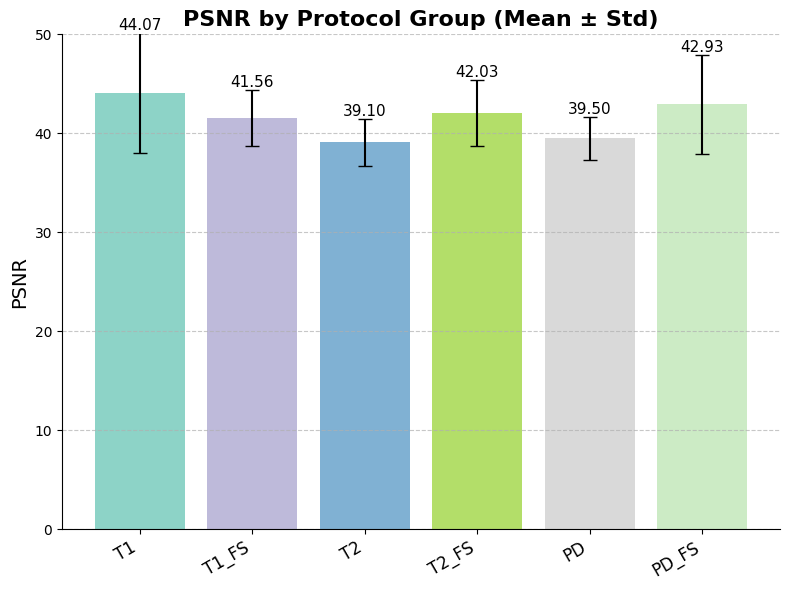

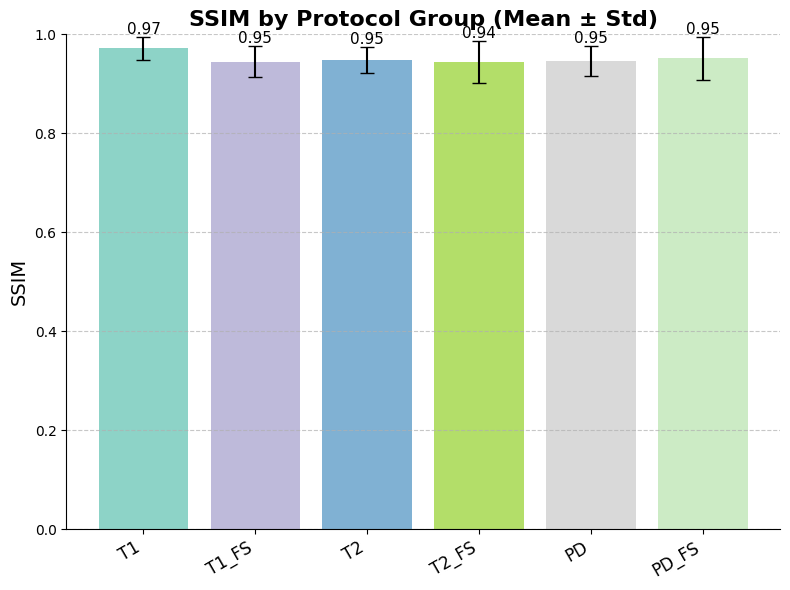

In [ ]:
# --------- Plot metrics by 6 protocol groups (T1, T1_FS, T2, T2_FS, PD, PD_FS) ----------
import xml.dom.minidom as _minidom

# Parse tProtocolName from ismrmrd_header
def parse_header_protocol(h5_path):
    try:
        with h5py.File(h5_path, "r") as f:
            if "ismrmrd_header" not in f:
                return None
            xml_raw = f["ismrmrd_header"][()]
            if isinstance(xml_raw, (bytes, bytearray, np.void)):
                xml_str = bytes(xml_raw).decode(errors="ignore")
            else:
                xml_str = str(xml_raw)
        dom = _minidom.parseString(xml_str)
        def _first_text(parent, tag):
            nodes = parent.getElementsByTagName(tag)
            if nodes and nodes[0].firstChild:
                return nodes[0].firstChild.data.strip()
            return None
        ups = dom.getElementsByTagName("userParameterString")
        for node in ups:
            name = _first_text(node, "name")
            if name == "tProtocolName":
                return _first_text(node, "value")
        return None
    except Exception:
        return None

# Map raw protocol to one of six protocol groups
def protocol_group(proto: str) -> str:
    if not proto:
        return None
    name = proto.upper()
    base = None
    if "T1" in name:
        base = "T1"
    elif "T2" in name:
        base = "T2"
    elif "PD" in name:
        base = "PD"
    else:
        return None
    has_fs = ("FS" in name) or ("DIXON" in name) or ("STIR" in name)
    return f"{base}_FS" if has_fs else base

# Build DataFrame with protocol groups
proto_rows = []
for fname, m in per_vol.items():
    h5_path = os.path.join(data_dir, fname)
    pg = protocol_group(parse_header_protocol(h5_path))
    if pg is None:
        continue
    proto_rows.append({
        "file": fname,
        "protocol_group": pg,
        "PSNR": m.get("PSNR"),
        "SSIM": m.get("SSIM"),
    })

df_proto = pd.DataFrame(proto_rows)

# Plot helper similar to category plots
def plot_metric_by_protocol(metric_name):
    if df_proto.empty:
        print("No protocol group data available to plot.")
        return
    proto_order = ["T1", "T1_FS", "T2", "T2_FS", "PD", "PD_FS"]
    g = df_proto.groupby("protocol_group")[metric_name]
    means = g.mean().reindex(proto_order).dropna()
    stds  = g.std().reindex(means.index)

    # Colors per protocol group
    cmap = plt.cm.Set3
    colors = [cmap(i / max(1, len(proto_order))) for i in range(len(proto_order))]
    bar_colors = [colors[proto_order.index(p)] if p in proto_order else "gray" for p in means.index]

    plt.figure(figsize=(8, 6))
    bars = plt.bar(range(len(means)), means.values, yerr=stds.values, capsize=5, color=bar_colors)
    plt.xticks(range(len(means)), means.index, rotation=30, ha='right', fontsize=12)
    plt.ylabel(metric_name, fontsize=14)
    plt.title(f"{metric_name} by Protocol Group (Mean ± Std)", fontsize=16, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().set_facecolor('white')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.ylim(0, 50.0 if metric_name == "PSNR" else 1.0)

    for bar, mean, std in zip(bars, means.values, stds.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (std if not np.isnan(std) else 0),
                 f"{mean:.2f}", ha='center', va='bottom', fontsize=11)
    plt.tight_layout()

# Generate protocol plots
for metric in ["PSNR", "SSIM"]:
    plot_metric_by_protocol(metric)
plt.show()

In [1]:
# === Additional PSNR plots: FS vs Non-FS and merged contrasts (T1_all, T2_all, PD_all, STIR) ===
import numpy as np
import matplotlib.pyplot as plt

# Academic-but-fun palette (consistent with earlier work)
PRO_COLORS = {
    'NON_FS': '#3366CC',
    'FS': '#DC3912',
    'T1_all': '#3366CC',
    'T2_all': '#DC3912',
    'PD_all': '#109618',
    'STIR': '#8E44AD',
}

# Reuse protocol parsing from earlier cell (parse_header_protocol). If missing, define a safe fallback.
try:
    parse_header_protocol
except NameError:
    import xml.dom.minidom as _minidom
    def parse_header_protocol(h5_path):
        try:
            with h5py.File(h5_path, "r") as f:
                if "ismrmrd_header" not in f:
                    return None
                xml_raw = f["ismrmrd_header"][()]
                if isinstance(xml_raw, (bytes, bytearray, np.void)):
                    xml_str = bytes(xml_raw).decode(errors="ignore")
                else:
                    xml_str = str(xml_raw)
            dom = _minidom.parseString(xml_str)
            def _first_text(parent, tag):
                nodes = parent.getElementsByTagName(tag)
                if nodes and nodes[0].firstChild:
                    return nodes[0].firstChild.data.strip()
                return None
            ups = dom.getElementsByTagName("userParameterString")
            for node in ups:
                name = _first_text(node, "name")
                if name == "tProtocolName":
                    return _first_text(node, "value")
            return None
        except Exception:
            return None

# Contrast grouping similar to dataset notebook
def get_contrast_group(proto: str) -> str:
    if not proto:
        return 'OTHER'
    name = proto.upper()
    if 'STIR' in name:
        return 'STIR'
    base = None
    if 'PD' in name:
        base = 'PD'
    elif 'T2' in name:
        base = 'T2'
    elif 'T1' in name:
        base = 'T1'
    else:
        return 'OTHER'
    has_fs = ('FS' in name) or ('DIXON' in name)
    return f"{base}_FS" if has_fs else base

# Build per-file protocol string if needed and compute FS label and merged contrast group
fs_rows = []
merged_rows = []
for fname, m in per_vol.items():
    h5_path = os.path.join(data_dir, fname)
    proto = parse_header_protocol(h5_path)
    if proto is None:
        continue
    psnr = m.get('PSNR')
    if psnr is None or np.isnan(psnr):
        continue

    name = proto.upper()
    is_fs = ('FS' in name) or ('DIXON' in name) or ('STIR' in name)
    fs_rows.append({
        'file': fname,
        'FS_flag': 'FS' if is_fs else 'NON_FS',
        'PSNR': psnr,
    })

    cg = get_contrast_group(proto)
    if cg == 'OTHER':
        continue
    if cg == 'STIR':
        merged = 'STIR'
    elif cg.startswith('T1'):
        merged = 'T1_all'
    elif cg.startswith('T2'):
        merged = 'T2_all'
    elif cg.startswith('PD'):
        merged = 'PD_all'
    else:
        continue
    merged_rows.append({
        'file': fname,
        'merged_group': merged,
        'PSNR': psnr,
    })

import pandas as pd

df_fs = pd.DataFrame(fs_rows)
df_merged = pd.DataFrame(merged_rows)

# --- Plot: PSNR on Non-FS vs FS ---
if df_fs.empty:
    print('No data available for FS vs Non-FS PSNR plot.')
else:
    order = ['NON_FS', 'FS']
    g = df_fs.groupby('FS_flag')['PSNR']
    means = g.mean().reindex(order).dropna()
    stds = g.std().reindex(means.index)

    plt.figure(figsize=(7, 6))
    colors = [PRO_COLORS.get(lbl, '#777777') for lbl in means.index]
    bars = plt.bar(range(len(means)), means.values, yerr=stds.values, capsize=5, color=colors, edgecolor='white', linewidth=0.8)
    plt.xticks(range(len(means)), means.index, fontsize=12)
    plt.ylabel('PSNR', fontsize=14)
    plt.title('PSNR by Fat Suppression (Mean ± Std)', fontsize=16, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    for bar, mean, std in zip(bars, means.values, stds.values):
        y = bar.get_height()
        off = 0 if np.isnan(std) else std
        plt.text(bar.get_x() + bar.get_width()/2, y + off, f"{mean:.2f}", ha='center', va='bottom', fontsize=11)
    plt.tight_layout()
    plt.show()

# --- Plot: PSNR on merged contrasts (T1_all, T2_all, PD_all, STIR) ---
if df_merged.empty:
    print('No data available for merged contrast PSNR plot.')
else:
    order = ['T1_all', 'T2_all', 'PD_all', 'STIR']
    g = df_merged.groupby('merged_group')['PSNR']
    means = g.mean().reindex(order).dropna()
    stds  = g.std().reindex(means.index)

    plt.figure(figsize=(8, 6))
    colors = [PRO_COLORS.get(lbl, '#777777') for lbl in means.index]
    bars = plt.bar(range(len(means)), means.values, yerr=stds.values, capsize=5, color=colors, edgecolor='white', linewidth=0.8)
    plt.xticks(range(len(means)), means.index, rotation=0, fontsize=12)
    plt.ylabel('PSNR', fontsize=14)
    plt.title('PSNR by Merged Contrast Group (Mean ± Std)', fontsize=16, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    for bar, mean, std in zip(bars, means.values, stds.values):
        y = bar.get_height()
        off = 0 if np.isnan(std) else std
        plt.text(bar.get_x() + bar.get_width()/2, y + off, f"{mean:.2f}", ha='center', va='bottom', fontsize=11)
    plt.tight_layout()
    plt.show()


NameError: name 'per_vol' is not defined